In [2]:
# # Asegurate de que el archivo en tu drive tenga el mismo nombre y esté en la misma dirección

# from google.colab import drive
# drive.mount('/content/drive')

# # Por que sino, lo siguiente va a tirar error
# import os
# os.chdir('/content/drive/MyDrive/TP1 (1)')

In [3]:
### Importaciones
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.ticker import PercentFormatter
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from PIL import Image
import os
import jinja2

# Ejercicio 1

## 1(a) LR sin PCA

In [4]:
def cargar_archivos(carpeta: str, csv: str):
  """
  Se suben las rutas a las carpetas y .csv's para poder trabajar con ellos.
  """
  df = pd.read_csv(csv) # archivo , clase

  imagenes = []
  for id in df["archivo"]:
      ruta = os.path.join(carpeta, id)
      img = Image.open(ruta).convert("L")  # abrir en escala de grises para evitar complicaciones
      img_array = np.array(img)            # matriz de 128x128
      imagenes.append(img_array.flatten()) # aplanar a vector

  X = np.array(imagenes)
  Y = df["clase"].values

  return X, Y

X_train, y_train = cargar_archivos("dataset_tp1/train", "dataset_tp1/train_labels.csv")
X_test, y_test = cargar_archivos("dataset_tp1/test", "dataset_tp1/test_labels.csv")


In [5]:
# Definición del modelo de clasificación de Regesión Logística
lr_model = LogisticRegression(max_iter=2000)

# Entrenamiento del modelo
lr_model.fit(X_train, y_train)

# Validación del modelo
y_pred = lr_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)



In [6]:
print(acc)

0.8183760683760684


## 1(b) Proyecciones en el espacio de componenetes principales

In [7]:
def ajustar_pca(X_train):
  """
  Centra y aplica SVD completa a X_train.
  """
  mu_X = X_train.mean(axis=0)
  X_centrada = X_train - mu_X

  # Se descarta U y S ya que se trabaja con V
  U, S, Vt = np.linalg.svd(X_centrada, full_matrices=False)
  V = Vt.T

  return mu_X, V

def proyectar(X, mu_X, V, K):
  """
  Proyección de X en las primeras K componentes
  """
  X_cent = X - mu_X
  V_k = V[:, :K]
  return X_cent @ V_k # Se podría usar U_k y S_k

In [8]:
mu_X, V = ajustar_pca(X_train)

Y_train2 = proyectar(X_train, mu_X, V, 2)
Y_test2 = proyectar(X_test, mu_X, V, 2)

In [ ]:
# --- Detector de entradas atípicas en el espacio PCA (K=2) ---
CLASES = [0, 1]

# Elipses teóricas de Mahalanobis al 99% en 2 dimensiones.
# chi-cuadrado con 2 grados de libertad: chi2_(2, 0.99) ≈ 9.21
UMBRAL_D2 = 9.21

medias_clase = {}
covarianzas_clase = {}
inversas_covarianza = {}

for clase in CLASES:
    # Ajuste con train
    puntos_train = Y_train2[y_train == clase]

    media = puntos_train.mean(axis=0)
    covarianza = np.cov(puntos_train, rowvar=False)

    # Regularización numérica mínima para poder invertir la covarianza
    epsilon = 1e-6 * np.trace(covarianza) / 2
    covarianza_reg = covarianza + epsilon * np.eye(2)

    medias_clase[clase] = media
    covarianzas_clase[clase] = covarianza_reg
    inversas_covarianza[clase] = np.linalg.inv(covarianza_reg)


def distancia_mahalanobis2(Y, media, covarianza_inversa):
    """
    Distancia de Mahalanobis al cuadrado de cada fila de Y
    respecto de una distribución gaussiana.
    """
    diferencia = Y - media

    # Cálculo de la distancia mahalonobis para cada imagen
    return np.einsum("ij,jk,ik->i", diferencia, covarianza_inversa, diferencia)


def distancias_a_clases(Y):
    """
    Devuelve una matriz:
    columna 0 -> distancia² a Normal
    columna 1 -> distancia² a Neumonía
    """
    return np.column_stack([
        distancia_mahalanobis2(Y, medias_clase[clase], inversas_covarianza[clase]) for clase in CLASES
        ])


# Se miden la cantidad de imagenes de test que son rechazadas
distancias_test = distancias_a_clases(Y_test2)
D2_min_test = distancias_test.min(axis=1)

aceptada_test = D2_min_test <= UMBRAL_D2

print(f"Umbral de aceptación: D² <= {UMBRAL_D2}")
print(f"Radiografías de test aceptadas: {aceptada_test.mean():.2%}")
print(f"Radiografías de test rechazadas como atípicas: {(~aceptada_test).mean():.2%}")

Umbral de aceptación: D² <= 9.21
Radiografías de test aceptadas: 99.36%
Radiografías de test rechazadas como atípicas: 0.64%


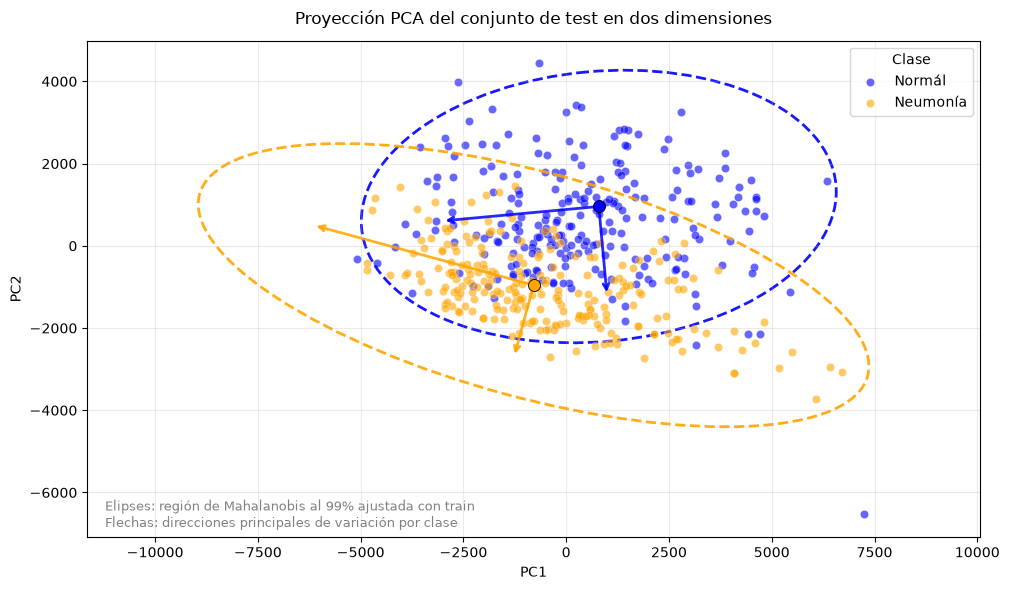

In [32]:
# Etiquetas y colores para ambas clases
etiqueta = {0: "Normál", 1: "Neumonía"}
colores = {0: "blue", 1: "orange"}

# # Se mide la proporción explicada de cada componente sobre la varianza total
# varianza_total = np.var(X_train, axis=0, ddof=1).sum()
# varianza_pc = np.var(Y_train2, axis=0, ddof=1)
# varianza_explicada = varianza_pc / varianza_total

fig, ax = plt.subplots(figsize=(10, 6))


for clase in [0, 1]:
    mask = y_test == clase
    puntos = Y_test2[mask]

    ax.scatter(puntos[:, 0], puntos[:, 1], label=etiqueta[clase], color=colores[clase], alpha=0.60,
        s=35, edgecolors="white", linewidths=0.3)

    # La elipse se ajusta con train, no con test
    mu = medias_clase[clase]

    autoval, autovec = np.linalg.eigh(covarianzas_clase[clase])

    orden = np.argsort(autoval)[::-1]
    autoval = autoval[orden]
    autovec = autovec[:, orden]

    angulo = np.degrees(np.arctan2(autovec[1, 0], autovec[0, 0]))

    # Elipse de Mahalanobis al 99%:
    # semiejes = sqrt(UMBRAL_D2) * sqrt(lambda)
    ancho, alto = 2 * np.sqrt(UMBRAL_D2) * np.sqrt(autoval)

    elipse = Ellipse( xy=mu, width=ancho, height=alto, angle=angulo, fill=False, edgecolor=colores[clase],
        linestyle="--", linewidth=2, alpha=0.9)
    ax.add_patch(elipse)

    # Centroide de la clase
    ax.scatter( mu[0], mu[1], color=colores[clase], marker="o", s=75, edgecolor="black",
        linewidth=0.6, zorder=4)

    # Direcciones principales de variación dentro de cada clase
    for i in range(2):
        direccion = 2 * np.sqrt(autoval[i]) * autovec[:, i]
        ax.annotate("", xy=mu + direccion, xytext=mu, arrowprops=dict( arrowstyle="->", color=colores[clase], lw=2, alpha=0.85))

ax.set_xlabel(f"PC1")
ax.set_ylabel(f"PC2")
ax.set_title("Proyección PCA del conjunto de test en dos dimensiones", pad=12)

ax.text(
    0.02, 0.02,
    "Elipses: región de Mahalanobis al 99% ajustada con train\n"
    "Flechas: direcciones principales de variación por clase",
    transform=ax.transAxes, fontsize=9, color="gray"
)

ax.grid(alpha=0.25)
ax.set_aspect("equal", adjustable="datalim")
ax.legend(title="Clase", frameon=True)

plt.tight_layout()
plt.show()

In [ ]:
# Out Of Distribution Detection

# ---  Primer criterio: Entradas sintéticas fuera de distribución ---
# Generador aleatorio
rng_ood = np.random.default_rng(2026)

# Se generan vectores para rpobar la detección 
n_ood = 100
n_pixeles = X_train.shape[1]

X_negra = np.zeros((n_ood, n_pixeles))
X_blanca = np.full((n_ood, n_pixeles), 255)
X_ruido = rng_ood.integers(
    low=0,
    high=256,
    size=(n_ood, n_pixeles)
)

X_ood = np.vstack([X_negra, X_blanca, X_ruido])

tipos_ood = np.repeat(
    ["Imagen negra", "Imagen blanca", "Ruido aleatorio"],
    n_ood
)

Y_ood = proyectar(X_ood, mu_X, V, 2)

distancias_ood = distancias_a_clases(Y_ood)
D2_min_ood = distancias_ood.min(axis=1)

In [ ]:
# --- Segundo criterio: error de reconstrucción PCA ---
# Cuando no todas las imágenes que deberíán ser descartadas  no lo son
K_RECONSTRUCCION_OOD = 20

def mse_residual_pca(X, k):
    """
    MSE de reconstrucción sin construir explícitamente la imagen reconstruida.

    Por ortonormalidad:
    ||X_c - X_hat_c||² = ||X_c||² - ||Y||²
    """
    X_centrado = X - mu_X
    Y = proyectar(X, mu_X, V, k)

    energia_total = np.sum(X_centrado ** 2, axis=1)
    energia_retenida = np.sum(Y ** 2, axis=1)

    return np.maximum(energia_total - energia_retenida, 0) / X.shape[1]


# El umbral se calibra solo con train
mse_train = mse_residual_pca(X_train, K_RECONSTRUCCION_OOD)
UMBRAL_MSE = np.quantile(mse_train, 0.99)

mse_test = mse_residual_pca(X_test, K_RECONSTRUCCION_OOD)
mse_ood = mse_residual_pca(X_ood, K_RECONSTRUCCION_OOD)

# Rechazo combinado:
# lejos de ambas clases O mala reconstrucción PCA
rechazo_distancia_test = D2_min_test > UMBRAL_D2
rechazo_reconstruccion_test = mse_test > UMBRAL_MSE

rechazo_final_test = (
    rechazo_distancia_test
    | rechazo_reconstruccion_test
)

rechazo_distancia_ood = D2_min_ood > UMBRAL_D2
rechazo_reconstruccion_ood = mse_ood > UMBRAL_MSE

rechazo_final_ood = (
    rechazo_distancia_ood | rechazo_reconstruccion_ood
)

print(f"Umbral MSE de reconstrucción: {UMBRAL_MSE:.2f}")
print(f"Test rechazado por distancia: {rechazo_distancia_test.mean():.2%}")
print(f"Test rechazado por MSE: {rechazo_reconstruccion_test.mean():.2%}")
print(f"Test rechazado por criterio combinado: {rechazo_final_test.mean():.2%}")

Umbral MSE de reconstrucción: 783.54
Test rechazado por distancia: 0.64%
Test rechazado por MSE: 2.99%
Test rechazado por criterio combinado: 3.42%


In [13]:


resumen_ood = pd.DataFrame({
    "Tipo de entrada": [
        "Radiografías de test",
        "Imagen negra",
        "Imagen blanca",
        "Ruido aleatorio"
    ],
    "Rechazo por distancia": [
        rechazo_distancia_test.mean(),
        rechazo_distancia_ood[tipos_ood == "Imagen negra"].mean(),
        rechazo_distancia_ood[tipos_ood == "Imagen blanca"].mean(),
        rechazo_distancia_ood[tipos_ood == "Ruido aleatorio"].mean()
    ],
    "Rechazo por reconstrucción": [
        rechazo_reconstruccion_test.mean(),
        rechazo_reconstruccion_ood[tipos_ood == "Imagen negra"].mean(),
        rechazo_reconstruccion_ood[tipos_ood == "Imagen blanca"].mean(),
        rechazo_reconstruccion_ood[tipos_ood == "Ruido aleatorio"].mean()
    ],
    "Rechazo combinado": [
        rechazo_final_test.mean(),
        rechazo_final_ood[tipos_ood == "Imagen negra"].mean(),
        rechazo_final_ood[tipos_ood == "Imagen blanca"].mean(),
        rechazo_final_ood[tipos_ood == "Ruido aleatorio"].mean()
    ]
})

display(
    resumen_ood.style.format({
        "Rechazo por distancia": "{:.1%}",
        "Rechazo por reconstrucción": "{:.1%}",
        "Rechazo combinado": "{:.1%}"
    })
)

,Tipo de entrada,Rechazo por distancia,Rechazo por reconstrucción,Rechazo combinado
0,Radiografías de test,0.6%,3.0%,3.4%
1,Imagen negra,100.0%,0.0%,100.0%
2,Imagen blanca,100.0%,0.0%,100.0%
3,Ruido aleatorio,0.0%,100.0%,100.0%


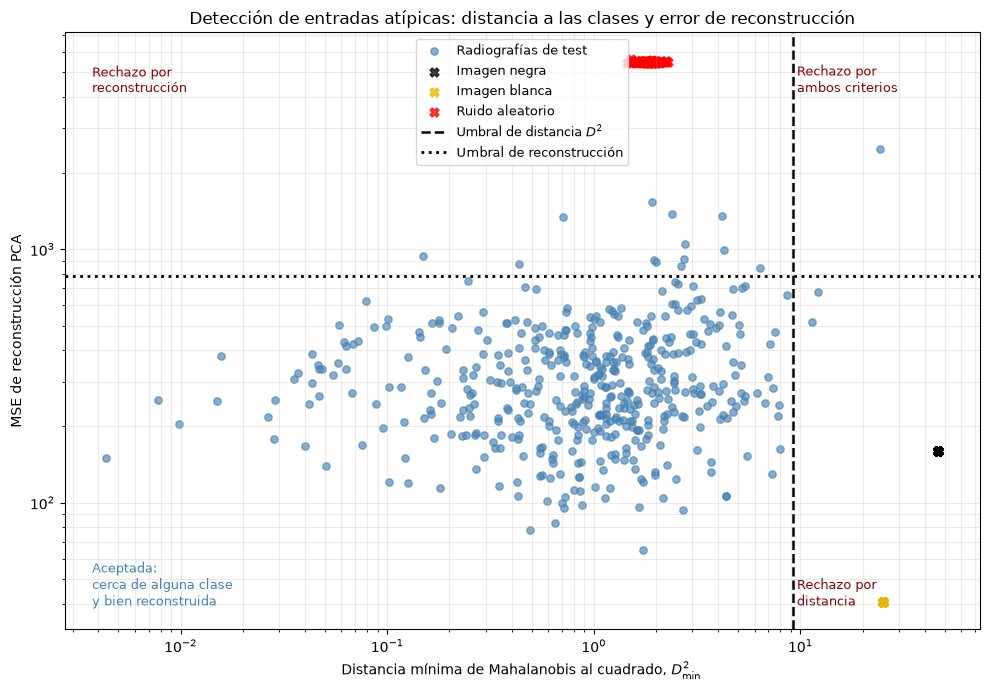

In [44]:
# --- Mapa conjunto: distancia de Mahalanobis vs. error de reconstrucción ---

fig, ax = plt.subplots(figsize=(10, 7))

# Radiografías reales de test
ax.scatter(
    np.maximum(D2_min_test, 1e-10),
    np.maximum(mse_test, 1e-10),
    color="steelblue",
    alpha=0.65,
    s=28,
    label="Radiografías de test"
)

# Entradas sintéticas atípicas
config_ood = {
    "Imagen negra": "black",
    "Imagen blanca": "#E6B800",
    "Ruido aleatorio": "red"
}

for tipo, color in config_ood.items():
    mask = tipos_ood == tipo

    ax.scatter(
        np.maximum(D2_min_ood[mask], 1e-10),
        np.maximum(mse_ood[mask], 1e-10),
        color=color, alpha=0.75, s=42, marker="X", label=tipo)

# Umbrales de rechazo
ax.axvline(UMBRAL_D2, color="black", linestyle="--", linewidth=1.8, label=r"Umbral de distancia $D^2$")

ax.axhline(UMBRAL_MSE, color="black", linestyle=":", linewidth=2, label="Umbral de reconstrucción")

# Escala log: permite ver test y entradas sintéticas en la misma figura
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"Distancia mínima de Mahalanobis al cuadrado, $D^2_{\min}$")
ax.set_ylabel("MSE de reconstrucción PCA")
ax.set_title(
    "Detección de entradas atípicas: distancia a las clases y error de reconstrucción"
            )

ax.text(
    0.03, 0.04,
    "Aceptada:\ncerca de alguna clase\ny bien reconstruida",
    transform=ax.transAxes, fontsize=9, color="steelblue")

ax.text(
    0.03, 0.9,
    "Rechazo por\nreconstrucción",
    transform=ax.transAxes, fontsize=9, color="darkred"
)

ax.text(
    0.8, 0.04,
    "Rechazo por\ndistancia",
    transform=ax.transAxes, fontsize=9, color="darkred")

ax.text(
    0.8, 0.9,
    "Rechazo por\nambos criterios", 
    transform=ax.transAxes, fontsize=9, color="darkred")

ax.grid(alpha=0.25, which="both")
ax.legend(loc="upper center", fontsize=9)

plt.tight_layout()
plt.show()

## 1(c) Análisis de desempeño según K

In [15]:
def desempeño(Ks: list[int]):
  """
  Genera un modelo y sus predicciones para distintos valores de K.
  Esto para observar los mejores K's.
  """
  accs = []
  for k in Ks:
      Y_traink = proyectar(X_train, mu_X, V, k)
      Y_testk = proyectar(X_test, mu_X, V, k)

      model_k = LogisticRegression(max_iter=2000)
      model_k.fit(Y_traink, y_train)

      y_pred = model_k.predict(Y_testk)
      acc_k = accuracy_score(y_test, y_pred)
      accs.append(acc_k)

  return accs

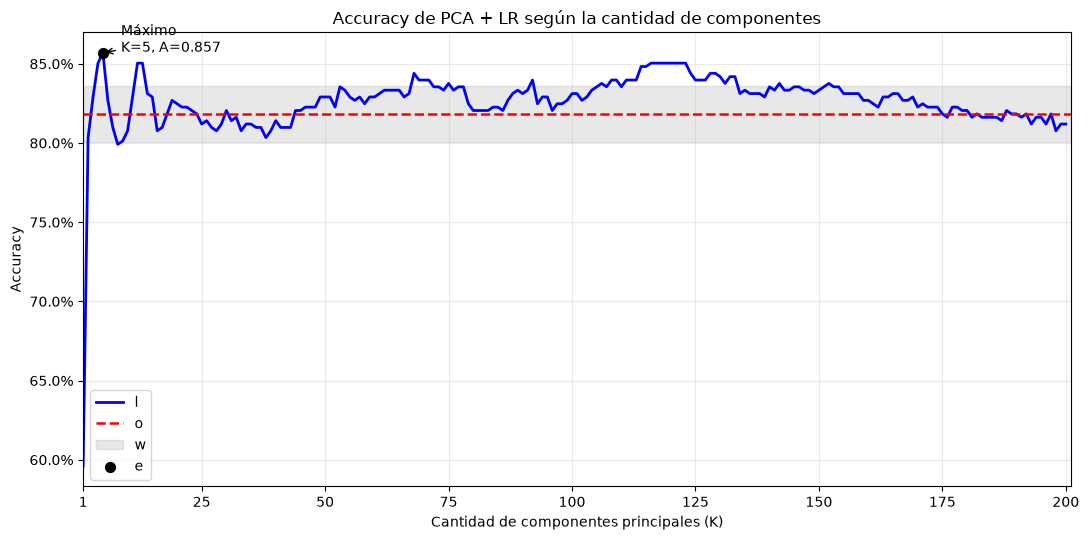

In [16]:
# Se eligen los K's y se busca el desempeño para cada uno.
# Tarda un poco por el arange, ya que tiene que medir el demepeño de 200 K's
K_values = np.arange(1, 201)
accuracys_Ks = desempeño(K_values)

n_test = len(y_test)
error_std = np.sqrt(acc * (1 - acc) / n_test)

mejor_K_indice = np.argmax(accuracys_Ks)
K_mejor = K_values[mejor_K_indice]
acc_mejor = accuracys_Ks[mejor_K_indice]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(K_values, accuracys_Ks, color="blue", linewidth=2, markersize=3, label="PCA + LR")

ax.axhline(acc, linestyle="--", color="red", linewidth=1.8, label=f"Baseline sin PCA ({acc:.3f})")
ax.axhspan(acc - error_std, acc + error_std, alpha=0.18, color="gray", label=f"Baseline ± 1SE ({error_std:.3f})")
ax.scatter(K_mejor, acc_mejor, color="black", s=50, zorder=4)
ax.annotate(f"Máximo\nK={K_mejor}, A={acc_mejor:.3f}", xy=(K_mejor, acc_mejor), xytext=(K_mejor + 8, acc_mejor + 0.01), 
            textcoords = "offset points", arrowprops=dict(arrowstyle="->", color="black"), color="black")

ax.set_xlabel("Cantidad de componentes principales (K)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy de PCA + LR según la cantidad de componentes")

ax.set_xlim(1, 201)
ax.set_xticks([1, 25, 50, 75, 100, 125, 150, 175, 200])
ax.yaxis.set_major_formatter(PercentFormatter(1))

ax.grid(True, alpha=0.25)
ax.legend("lower right")
plt.tight_layout()
plt.show()

In [17]:
resultados = pd.DataFrame({
    "K": K_values,
    "Accuracy": accuracys_Ks
})

resultados["Diferencia vs. baseline"] = resultados["Accuracy"] - acc

display(resultados[resultados["K"].isin([1, 5, 20, 50, 100, 150, 200])].style.format({
        "Accuracy": "{:.4f}",
        "Diferencia vs. baseline": "{:+.4f}"
    })
)



,K,Accuracy,Diferencia vs. baseline
0,1,0.5962,-0.2222
4,5,0.8568,+0.0385
19,20,0.8248,+0.0064
49,50,0.8291,+0.0107
99,100,0.8312,+0.0128
149,150,0.8333,+0.0150
199,200,0.8120,-0.0064


## Análisis de Resultados

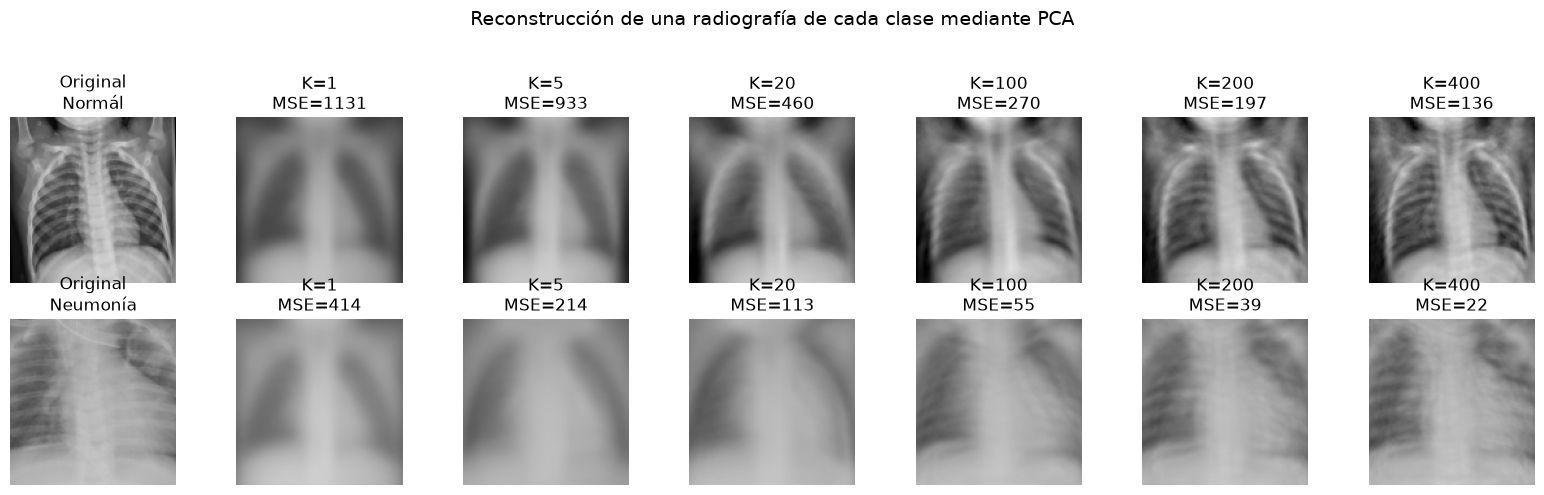

In [18]:
# Reconstrucción de una imagen X = YV_k^T + mu_X (X con ~)
def reconstruccion(X, mu_X, V, k):
  """
  Reconstruye X con k componentes principales.
  """
  Y = proyectar(X, mu_X, V, k)
  V_k = V[:, :k]
  x_reconstruida = Y @ V_k.T + mu_X

  return x_reconstruida

indices = [
    np.where(y_test == 0)[0][0],  # una Normal
    np.where(y_test == 1)[0][0],  # una con Neumonía
]
etiqueta = {0: "Normál", 1: "Neumonía"}

K_elegidos = [1, 5, 20, 100, 200, 400]
# # Cualquier imagen
# img = Image.open("dataset_tp1/train/PMINST_0002.png").convert("L")
# img_array = np.array(img)
# img_flatten = img_array.flatten()[None, :] # Se aplana el array

fig, axes = plt.subplots(2, len(K_elegidos) + 1, figsize=(16, 5))

for fila, (clase, indice) in enumerate(zip([0, 1], indices)):
  img_flatten = X_test[indice][None, :]
  img_array = X_test[indice].reshape(128, 128)

  # La primer imagen es la original
  axes[fila, 0].imshow(img_array, cmap="gray", vmin=0, vmax=255)
  axes[fila, 0].set_title(f"Original\n{etiqueta[clase]}")
  axes[fila, 0].axis("off")

  for ax, K in zip(axes[fila, 1:], K_elegidos):
    img_reconstruida = reconstruccion(img_flatten, mu_X, V, K)
    mse = np.mean((img_flatten - img_reconstruida) ** 2)

    ax.imshow(np.clip(img_reconstruida[0], 0, 255).reshape(128, 128), cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"K={K}\nMSE={mse:.0f}")
    ax.axis("off")

fig.suptitle("Reconstrucción de una radiografía de cada clase mediante PCA", fontsize=14, y=0.98)


plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

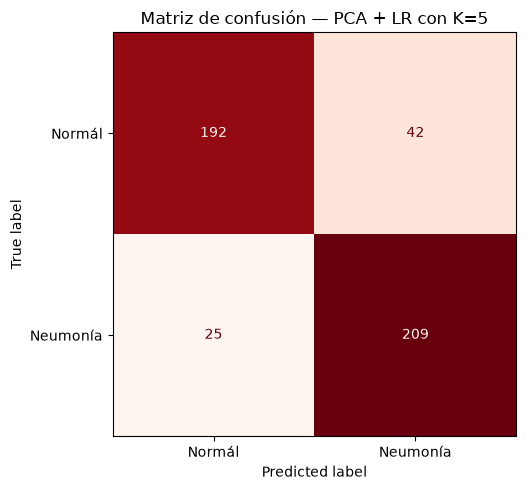

In [19]:
# Falsos positivos y Falsos Negativos para K = 5,
# que fue el mejor dentro del intervalo [1, 200]
K_elegido = K_mejor

# proyecta y se vuelve a entrenar un modelo
Y_train_k = proyectar(X_train, mu_X, V, K_elegido)
Y_test_k = proyectar(X_test, mu_X, V, K_elegido)

modelo_final = LogisticRegression(max_iter=2000)
modelo_final.fit(Y_train_k, y_train)

# Se testea el modelo
y_pred_k = modelo_final.predict(Y_test_k)

# Esta matriz muestra en cuantos casos hubo FP y FN
matriz_confusion = confusion_matrix(y_test, y_pred_k)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(confusion_matrix=matriz_confusion,
display_labels=["Normál", "Neumonía"]).plot(ax=ax, cmap="Reds", colorbar=False)

ax.set_title(f"Matriz de confusión — PCA + LR con K={K_elegido}")
plt.tight_layout()
plt.show()

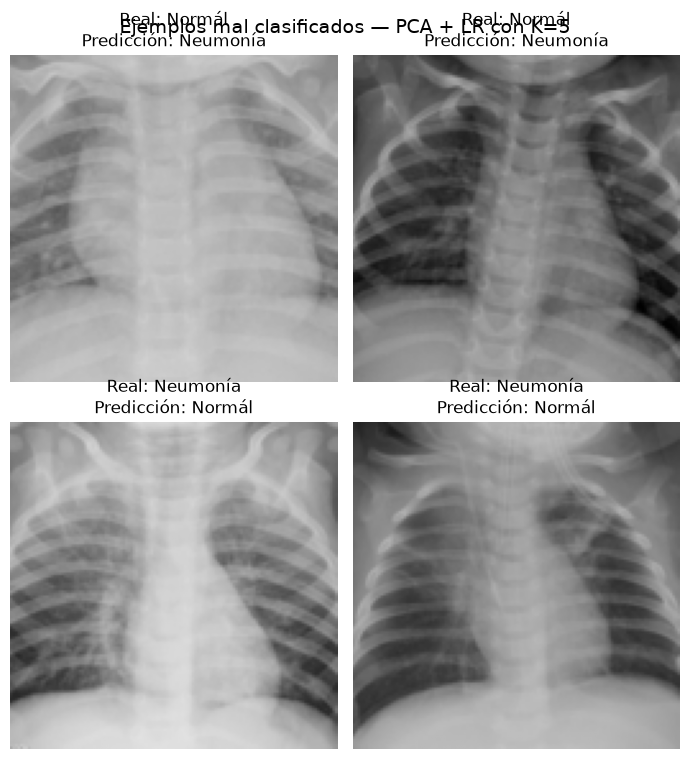

In [20]:
# Visualización de FN's y FP's
etiqueta = {0: "Normál", 1: "Neumonía"}

# Normal predicha como Neumonía
FP = np.where((y_test == 0) & (y_pred_k == 1))[0][:2]
# Neumonía predicha como Normal
FN = np.where((y_test == 1) & (y_pred_k == 0))[0][:2]

indices_error = np.concatenate([FP, FN])
fig, axes = plt.subplots(2, 2, figsize=(7, 8))

for ax, indice in zip(axes.ravel(), indices_error):
    ax.imshow(X_test[indice].reshape(128, 128), cmap="gray", vmin=0, vmax=255)

    clase_real = etiqueta[y_test[indice]]
    clase_predicha = etiqueta[y_pred_k[indice]]

    ax.set_title(f"Real: {clase_real}\nPredicción: {clase_predicha}")
    ax.axis("off")

fig.suptitle(f"Ejemplos mal clasificados — PCA + LR con K={K_elegido}", fontsize=14, y=0.94)

plt.tight_layout()
plt.show()

# Ejercicio 2

In [21]:
# Parámetros
K_MC = 2
P_VALUES = np.arange(0.1, 1.0, 0.1)
N_MC = 500
DELTA = 0.1
SEED = 37

# Proyectamos train y test con K=2.
# PCA ya fue ajustado usando solamente X_train.
Y_train_mc = proyectar(X_train, mu_X, V, K_MC)
Y_test_original = proyectar(X_test, mu_X, V, K_MC)

# Recuperamos la forma cuadrada de las imágenes.
lado = int(np.sqrt(X_test.shape[1]))

if lado * lado != X_test.shape[1]:
    raise ValueError(
        "Las imágenes no son cuadradas; hay que indicar su alto y ancho."
    )

# Rotamos todas las imágenes de test 180°.
X_test_rotado = np.rot90(
    X_test.reshape(-1, lado, lado),
    k=2,
    axes=(1, 2)
).reshape(X_test.shape)

# Proyectamos también las imágenes rotadas usando el mismo PCA.
Y_test_rotado = proyectar(X_test_rotado, mu_X, V, K_MC)

# Entrenamos PCA+LR una única vez con train sin perturbar.
modelo_mc = LogisticRegression(max_iter=2000)
modelo_mc.fit(Y_train_mc, y_train)

# Accuracy base sin perturbaciones.
pred_original = modelo_mc.predict(Y_test_original)
A0 = accuracy_score(y_test, pred_original)

print(f"Accuracy base A0 con K={K_MC}: {A0:.4f}")

Accuracy base A0 con K=2: 0.8034


Para cada imagen se genera una variable Bernoulli de parámetro $P.$ Si el resultado es 1, se utiliza la imagen rotada; si es 0, se utiliza la imagen original. PCA y el clasificador permanecen fijos durante todo el experimento.

In [22]:
def muestra_perturbada_pca(p, rng):
    """
    Genera una realización del conjunto de test perturbado.

    Cada imagen se rota con probabilidad p y permanece
    sin modificar con probabilidad 1-p.
    """
    rotar = rng.random(len(y_test)) < p

    Y_perturbado = np.where(
        rotar[:, None],
        Y_test_rotado,
        Y_test_original
    )

    return Y_perturbado, rotar

## 2(a) Proyección de una realización perturbada para cada valor de $P$

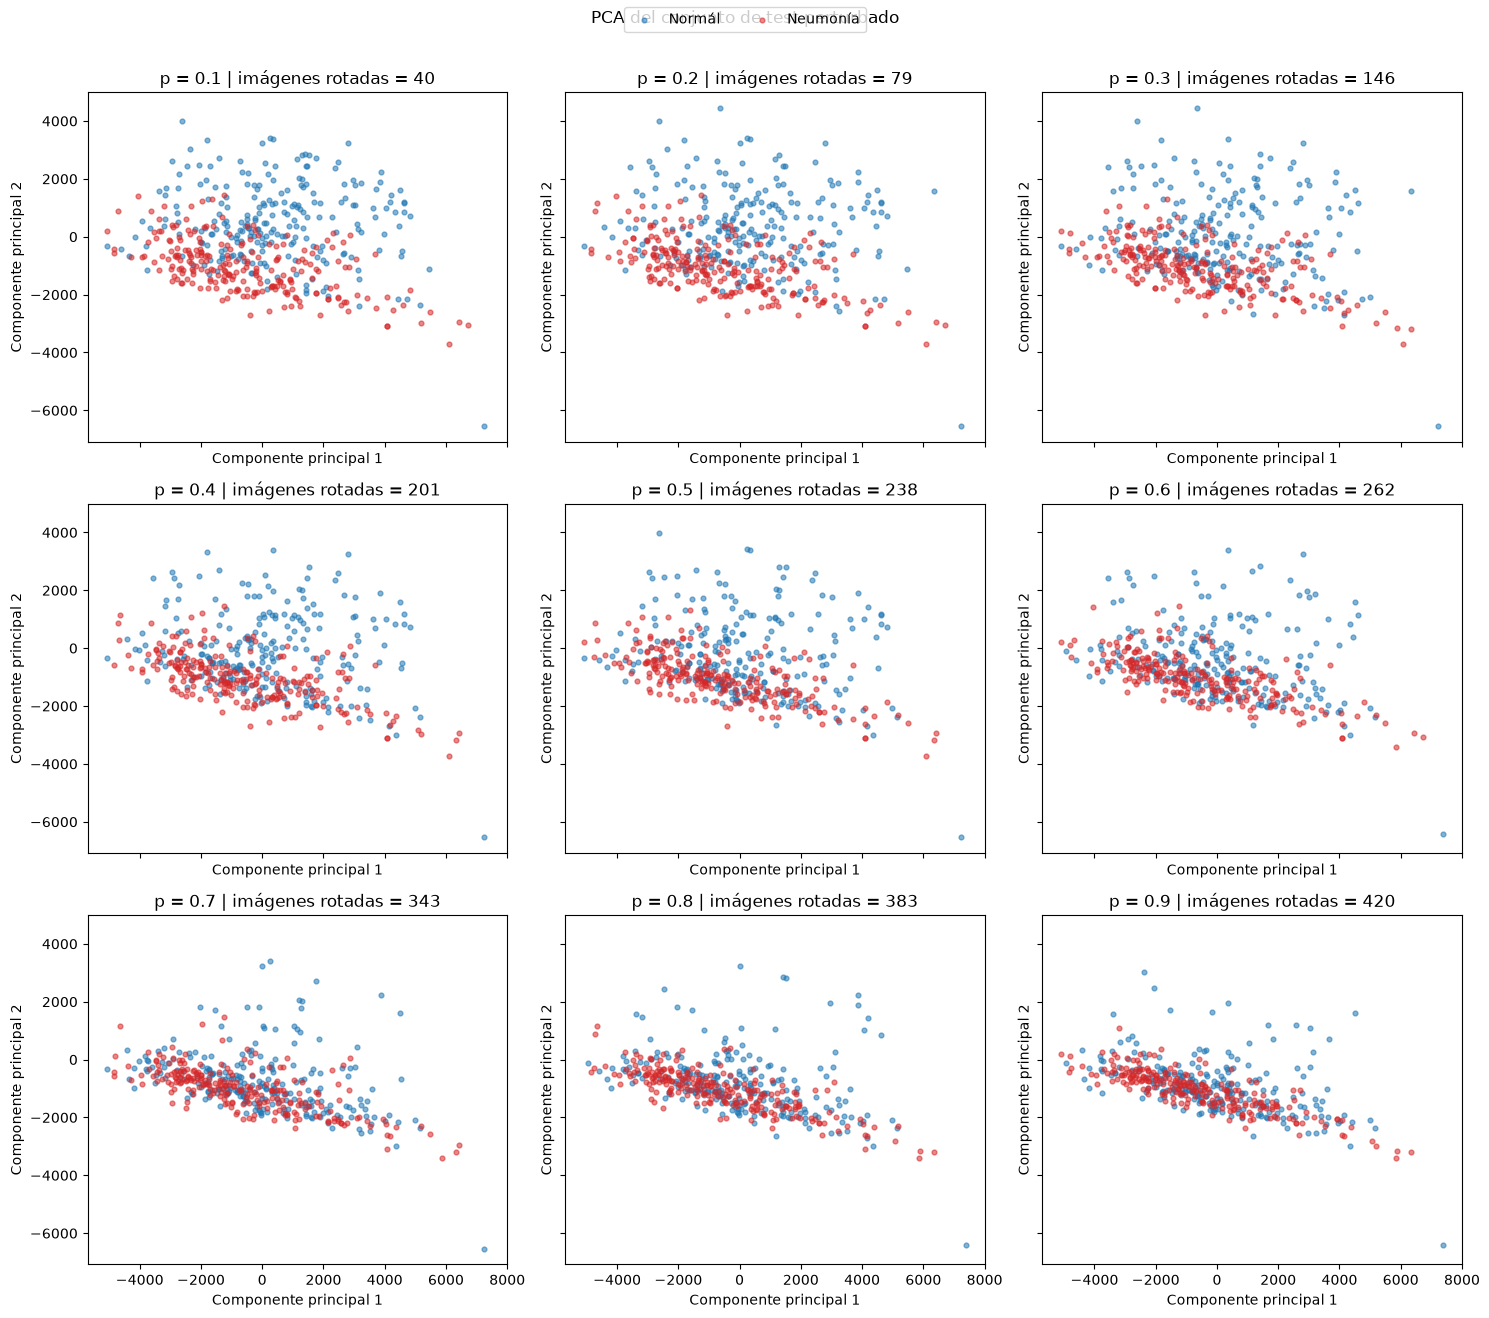

In [23]:
rng_scatter = np.random.default_rng(SEED)

fig, axes = plt.subplots(
    3, 3,
    figsize=(15, 13),
    sharex=True,
    sharey=True
)

for ax, p in zip(axes.ravel(), P_VALUES):
    Y_p, rotadas = muestra_perturbada_pca(p, rng_scatter)

    for clase, nombre, color_clase in [
        (0, "Normál", "tab:blue"),
        (1, "Neumonía", "tab:red")
    ]:
        mask = y_test == clase

        ax.scatter(
            Y_p[mask, 0],
            Y_p[mask, 1],
            s=12,
            alpha=0.55,
            color=color_clase,
            label=nombre
        )

    ax.set_title(
        f"p = {p:.1f} | imágenes rotadas = {rotadas.sum()}"
    )
    ax.set_xlabel("Componente principal 1")
    ax.set_ylabel("Componente principal 2")

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2
)

fig.suptitle(
    "PCA del conjunto de test perturbado",
    y=1.01
)

fig.tight_layout()
plt.show()

In [24]:
def simulacion_monte_carlo(p_values, n_mc, seed=37):
    """
    Realiza n_mc simulaciones independientes para cada p.

    Devuelve una matriz:
        filas    -> valores de p
        columnas -> realizaciones Monte Carlo
    """
    rng = np.random.default_rng(seed)

    accuracies = np.empty(
        (len(p_values), n_mc)
    )

    for j, p in enumerate(p_values):
        for i in range(n_mc):
            Y_perturbado, _ = muestra_perturbada_pca(p, rng)

            pred = modelo_mc.predict(Y_perturbado)

            accuracies[j, i] = accuracy_score(
                y_test,
                pred
            )

    return accuracies


accuracies_mc = simulacion_monte_carlo(
    P_VALUES,
    N_MC,
    seed=SEED
)


## 2(b) Estimación del accuracy medio

Para cada $p$, se estima $E[A_p]$ promediando los accuracies obtenidos en las $N_{MC}$ simulaciones independientes.

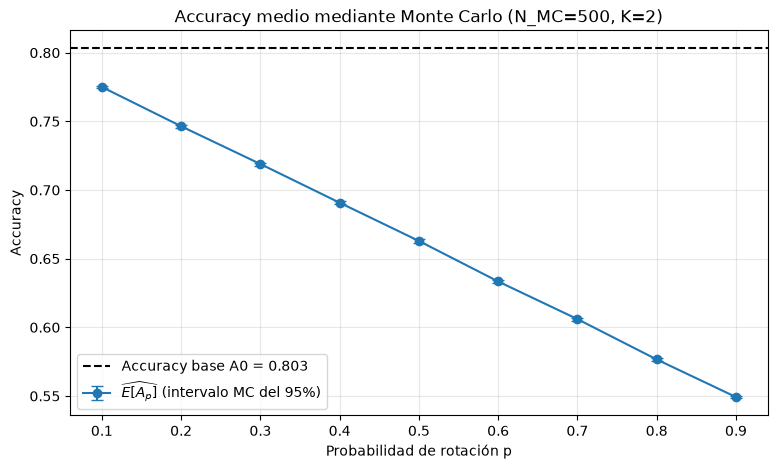

,p,accuracy_medio,error_estandar_MC
0,0.1,0.775034,0.000389
1,0.2,0.746427,0.000532
2,0.3,0.718919,0.000565
3,0.4,0.690756,0.000640
4,0.5,0.662897,0.000667
5,0.6,0.633402,0.000658
6,0.7,0.605979,0.000597
7,0.8,0.576615,0.000529
8,0.9,0.549239,0.000353


In [25]:
accuracy_medio = accuracies_mc.mean(axis=1)

# Error estándar de la estimación Monte Carlo
accuracy_error = (
    accuracies_mc.std(axis=1, ddof=1)
    / np.sqrt(N_MC)
)

plt.figure(figsize=(9, 5))

plt.errorbar(
    P_VALUES,
    accuracy_medio,
    yerr=1.96 * accuracy_error,
    marker="o",
    capsize=4,
    label=r"$\widehat{E[A_p]}$ (intervalo MC del 95%)"
)

plt.axhline(
    A0,
    color="black",
    linestyle="--",
    label=f"Accuracy base A0 = {A0:.3f}"
)

plt.xlabel("Probabilidad de rotación p")
plt.ylabel("Accuracy")
plt.title(
    f"Accuracy medio mediante Monte Carlo "
    f"(N_MC={N_MC}, K={K_MC})"
)
plt.xticks(P_VALUES)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

resultados = pd.DataFrame({
    "p": P_VALUES,
    "accuracy_medio": accuracy_medio,
    "error_estandar_MC": accuracy_error
})

resultados

## 2(c) Probabilidad de que la pérdida supere $delta=0.1$

Para cada simulación se calcula

$
L_i(p)=A_0-A_{p,i}.
$

La probabilidad \$P(L(p)>\delta)$ se estima mediante la frecuencia relativa de las simulaciones en las cuales la pérdida supera la tolerancia.

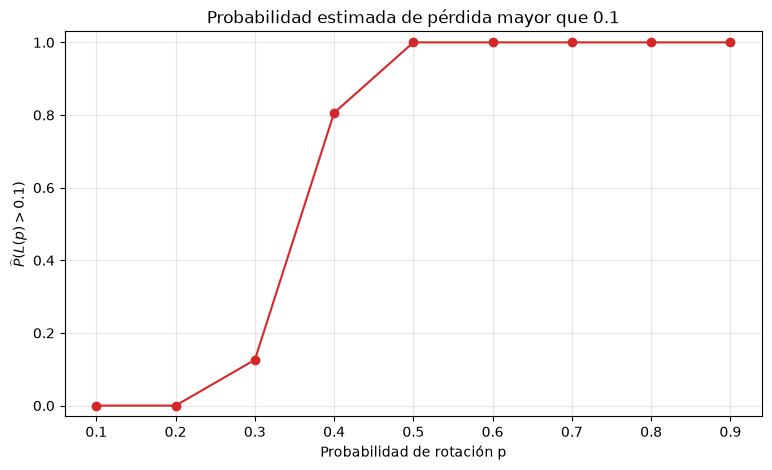

,p,accuracy_medio,error_estandar_MC,P(L>0.1)
0,0.1,0.775034,0.000389,0.000
1,0.2,0.746427,0.000532,0.000
2,0.3,0.718919,0.000565,0.126
3,0.4,0.690756,0.000640,0.806
4,0.5,0.662897,0.000667,1.000
5,0.6,0.633402,0.000658,1.000
6,0.7,0.605979,0.000597,1.000
7,0.8,0.576615,0.000529,1.000
8,0.9,0.549239,0.000353,1.000


In [26]:
# L_i(p) = A0 - A_{p,i}
perdidas_mc = A0 - accuracies_mc

# Indicadora del evento L_i(p) > DELTA
indicadoras = perdidas_mc > DELTA

# Promedio de las indicadoras
prob_supera_delta = indicadoras.mean(axis=1)

plt.figure(figsize=(9, 5))

plt.plot(
    P_VALUES,
    prob_supera_delta,
    marker="o",
    color="tab:red"
)

plt.xlabel("Probabilidad de rotación p")
plt.ylabel(r"$\widehat{P}(L(p)>0.1)$")
plt.title(
    f"Probabilidad estimada de pérdida mayor que {DELTA}"
)
plt.xticks(P_VALUES)
plt.ylim(-0.03, 1.03)
plt.grid(alpha=0.3)
plt.show()

resultados["P(L>0.1)"] = prob_supera_delta

resultados

## 2(d) Distribución empírica de los accuracies

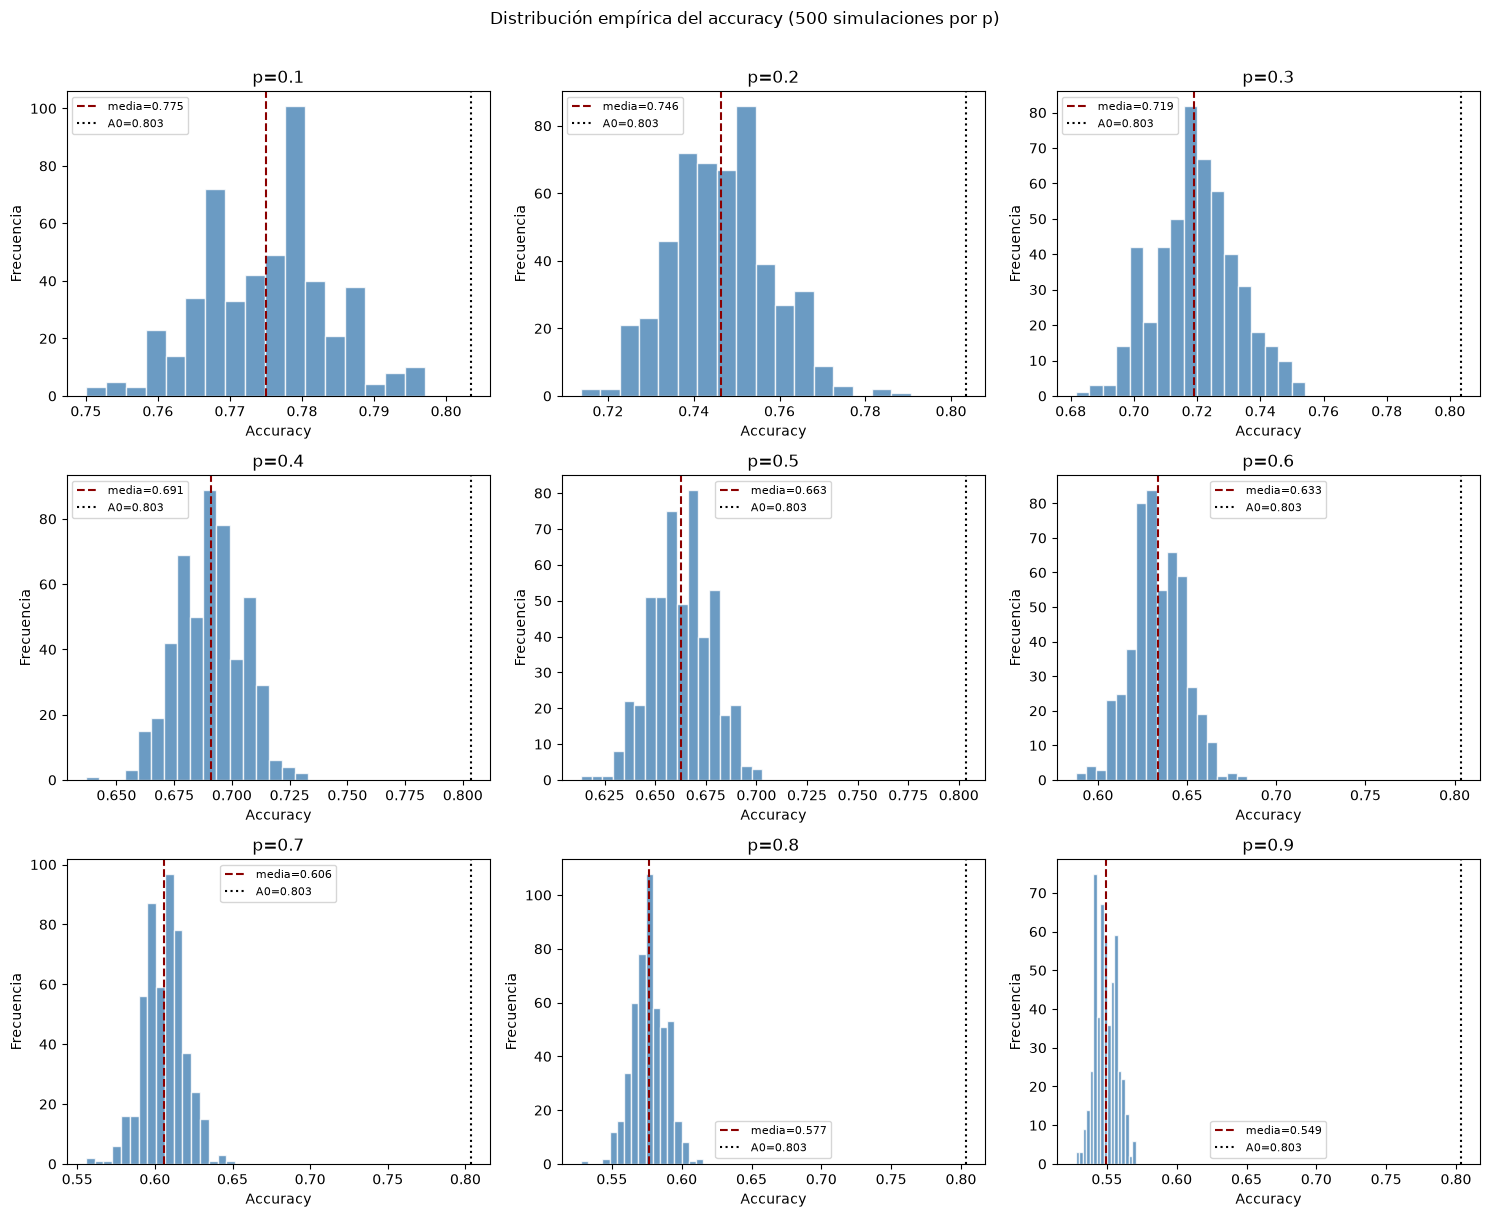

In [27]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12)) 

for ax, p, acc_p, media_p in zip(axes.ravel(), P_VALUES, accuracies_mc, accuracy_medio):
    bins_p = np.linspace(acc_p.min(), acc_p.max(), 18)  # rango propio de este p
    ax.hist(acc_p, bins=bins_p, alpha=0.8, color="steelblue", edgecolor="white")
    ax.axvline(media_p, color="darkred", linestyle="--", label=f"media={media_p:.3f}")
    ax.axvline(A0, color="black", linestyle=":", label=f"A0={A0:.3f}")
    ax.set_title(f"p={p:.1f}")
    ax.set_xlabel("Accuracy")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=8)

fig.suptitle(f"Distribución empírica del accuracy ({N_MC} simulaciones por p)", y=1.01)
fig.tight_layout()
plt.show()

## Interpretación

Al aumentar $p$, una mayor proporción de las radiografías pierde la orientación utilizada durante el entrenamiento de PCA y del clasificador. En consecuencia, se espera que el accuracy medio disminuya y que aumente la probabilidad de que la pérdida supere la tolerancia $delta=0.1$.

Los histogramas muestran la distribución empírica del accuracy para cada valor de $p.$ Su dispersión se debe a que en cada realización Monte Carlo cambia el subconjunto de imágenes rotadas.

PCA y el clasificador se entrenaron una sola vez con el conjunto de entrenamiento sin perturbar. Durante las simulaciones se modificó exclusivamente el conjunto de prueba, como exige la consigna.

# Ejercicio 3

Para un valor fijo de p, se define $Z_i=\mathbb{1}\{L_i(p)>\delta\},$ donde ($Z_i=1$) si la pérdida de la simulación ($i$) supera la tolerancia ($\delta$), y ($Z_i=0$) en caso contrario. Como cada realización Monte Carlo se genera de forma independiente aplicando el mismo mecanismo de perturbación, las variables ($Z_i$) son i.i.d. Bernoulli con parámetro $ \theta=\mathbb{P}_p(L(p)>\delta).$ Por lo tanto, ($\mathbb{E}[Z_i]=\theta$) y, por la Ley de los Grandes Números,

$$\widehat{\mathbb{P}}_p(L(p)>\delta)=\frac{1}{N_{MC}}\sum_{i=1}^{N_{MC}} Z_i \xrightarrow[N_{MC}\to\infty]{c.s.} \theta.$$

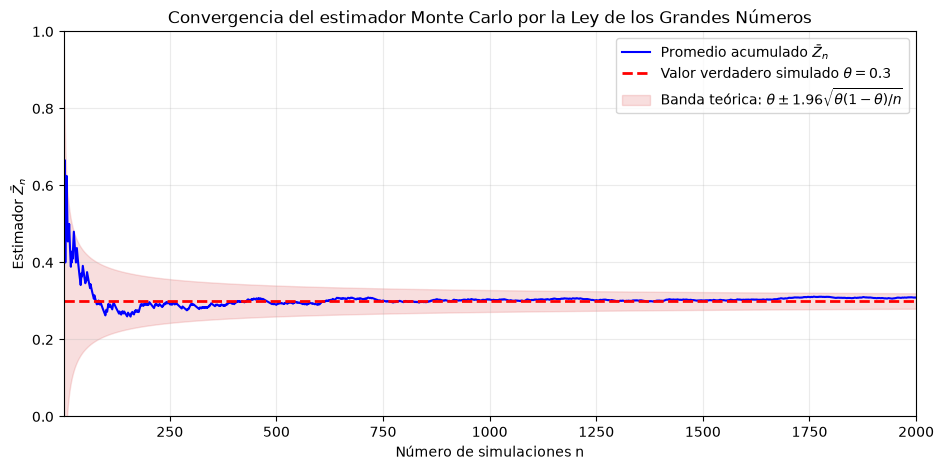

In [28]:
# Simulación que prueba esto

#elección de theta
theta = 0.3
n_max = 2000
rng = np.random.default_rng(42)

Z = rng.binomial(n = 1, p=theta, size=n_max)

n = np.arange(1, n_max + 1)
promedio_acumulado = np.cumsum(Z) / n

# Desvío estándar teórico
std_teorico = np.sqrt(theta * (1 - theta) / n)

# Intervalo donde la probabilidad de que Z_n esté dentro 
inferior = np.clip(theta - 1.96 * std_teorico, 0, 1)
superior = np.clip(theta + 1.96 * std_teorico, 0, 1)

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(n, promedio_acumulado, color="blue", linewidth=1.5, label=r"Promedio acumulado $\bar{Z}_n$")
ax.axhline(theta, color="red", linestyle="--", linewidth=2, label=fr"Valor verdadero simulado $\theta={theta}$")
ax.fill_between(n, inferior, superior, color="#dd4b4b", alpha=0.18, label=r"Banda teórica: $\theta \pm 1.96\sqrt{\theta(1-\theta)/n}$")

ax.set_xlabel("Número de simulaciones n")
ax.set_ylabel(r"Estimador $\bar{Z}_n$")
ax.set_title("Convergencia del estimador Monte Carlo por la Ley de los Grandes Números")

ax.set_xlim(1, n_max)
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
ax.legend()

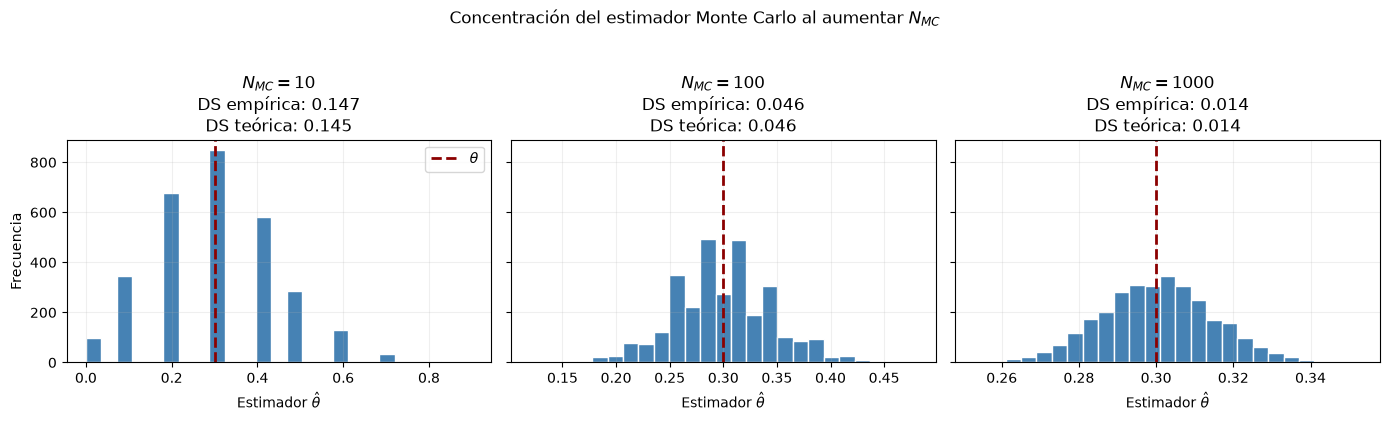

In [29]:
n_repeticiones = 3000
valores_n_mc = [10, 100, 1000]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, n_mc in zip(axes, valores_n_mc):
    estimadores = rng.binomial(n=1, p=theta, size=(n_repeticiones, n_mc)).mean(axis=1)
    desvio_teorico = np.sqrt(theta * (1 - theta) / n_mc)

    ax.hist(estimadores, bins=25, color="steelblue", edgecolor="white")
    ax.axvline(theta, color="darkred", linestyle="--", linewidth=2, label=r"$\theta$")
    ax.set_title(
        f"$N_{{MC}}={n_mc}$\n"
        f"DS empírica: {estimadores.std(ddof=1):.3f}\n"
        f"DS teórica: {desvio_teorico:.3f}"
    )
    ax.set_xlabel(r"Estimador $\hat{\theta}$")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Frecuencia")
axes[0].legend()

fig.suptitle("Concentración del estimador Monte Carlo al aumentar $N_{MC}$", y=1.04)
plt.tight_layout()
plt.show()